In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/iamkartikb/noughat/submission.parquet
/kaggle/input/notebooks/iamkartikb/noughat/__results__.html
/kaggle/input/notebooks/iamkartikb/noughat/__notebook__.ipynb
/kaggle/input/notebooks/iamkartikb/noughat/__output__.json
/kaggle/input/notebooks/iamkartikb/noughat/custom.css


In [4]:
!pip install -q transformers peft bitsandbytes accelerate qwen-vl-utils einops

In [5]:
import os
import torch
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoTokenizer,
    AutoProcessor,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

print("Libraries imported ✓")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU count: {torch.cuda.device_count()}")

Libraries imported ✓
GPU available: True
GPU count: 2


In [6]:
# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# Load model
model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

# Load processor
processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    trust_remote_code=True
)

print("Model loaded ✓")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded ✓


In [8]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/notebooks/iamkartikb/noughat/submission.parquet
/kaggle/input/notebooks/iamkartikb/noughat/__results__.html
/kaggle/input/notebooks/iamkartikb/noughat/__notebook__.ipynb
/kaggle/input/notebooks/iamkartikb/noughat/__output__.json
/kaggle/input/notebooks/iamkartikb/noughat/custom.css


In [10]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:20]:  # sirf pehli 20 files
        print(os.path.join(dirname, filename))

/kaggle/input/notebooks/iamkartikb/noughat/submission.parquet
/kaggle/input/notebooks/iamkartikb/noughat/__results__.html
/kaggle/input/notebooks/iamkartikb/noughat/__notebook__.ipynb
/kaggle/input/notebooks/iamkartikb/noughat/__output__.json
/kaggle/input/notebooks/iamkartikb/noughat/custom.css
/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508.jsonl
/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508131/03.png
/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508131/03.mmd
/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508131/meta.json
/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508131/04.mmd
/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508131/04.png
/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508089/02.mmd
/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508

In [11]:
import os
import glob
from pathlib import Path

DATASET_PATH = '/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508'

# find PNG images 
image_files = sorted(glob.glob(f'{DATASET_PATH}/**/*.png', recursive=True))

# for every image find a matching .mmd file 
pairs = []
for img_path in image_files:
    mmd_path = img_path.replace('.png', '.mmd')
    if os.path.exists(mmd_path):
        pairs.append({'image': img_path, 'markdown': mmd_path})

print(f"Total image-markdown pairs found: {len(pairs)}")
print(f"\nExample pair:")
print(f"Image   : {pairs[0]['image']}")
print(f"Markdown: {pairs[0]['markdown']}")

Total image-markdown pairs found: 14236

Example pair:
Image   : /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508001/01.png
Markdown: /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508001/01.mmd


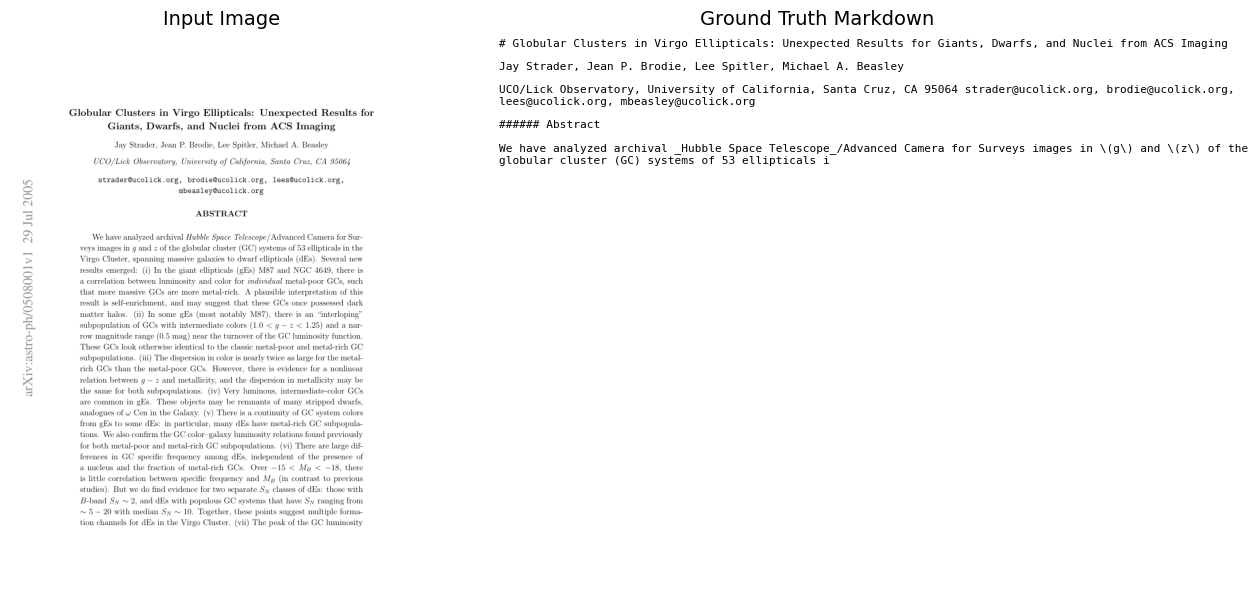


Markdown preview:
# Globular Clusters in Virgo Ellipticals: Unexpected Results for Giants, Dwarfs, and Nuclei from ACS Imaging

Jay Strader, Jean P. Brodie, Lee Spitler, Michael A. Beasley

UCO/Lick Observatory, University of California, Santa Cruz, CA 95064 strader@ucolick.org, brodie@ucolick.org, lees@ucolick.org, 


In [12]:
from PIL import Image
import matplotlib.pyplot as plt

sample = pairs[0]

# Image load 
img = Image.open(sample['image'])

# Markdown text 
with open(sample['markdown'], 'r', encoding='utf-8') as f:
    markdown_text = f.read()

# Display 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img)
axes[0].set_title('Input Image', fontsize=14)
axes[0].axis('off')

axes[1].text(0.01, 0.99, markdown_text[:500], 
             transform=axes[1].transAxes,
             fontsize=8, verticalalignment='top',
             fontfamily='monospace', wrap=True)
axes[1].set_title('Ground Truth Markdown', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\nMarkdown preview:")
print(markdown_text[:300])

In [14]:
import random

# Shuffle aur split 
random.seed(42)
random.shuffle(pairs)

#  500 samples 
pairs = pairs[:500]

split = int(0.8 * len(pairs))
train_pairs = pairs[:split]
val_pairs   = pairs[split:]

print("Training samples  :", len(train_pairs))
print("Validation samples:", len(val_pairs))

# ChatML format function
def make_chatml(image_path, markdown_path):
    with open(markdown_path, 'r', encoding='utf-8') as f:
        markdown_text = f.read()
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": "Convert this document image to Markdown."}
            ]
        },
        {
            "role": "assistant",
            "content": markdown_text
        }
    ]
    return messages

# Testing
sample_msg = make_chatml(train_pairs[0]['image'], train_pairs[0]['markdown'])
print("\nChatML format ready!")
print("Image path:", sample_msg[0]['content'][0]['image'])
print("Markdown preview:", sample_msg[1]['content'][:100])

Training samples  : 400
Validation samples: 100

ChatML format ready!
Image path: /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/cond-mat0508072/17.png
Markdown preview: sigma_{0}\) as indicated by \(S(z)\to-1/2\). This observation is merely due to the electrostatic wal


In [15]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# prepare for model training
model = prepare_model_for_kbit_training(model)

# LoRA config
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# LoRA model 
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 2,179,072 || all params: 2,211,164,672 || trainable%: 0.0985


In [16]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch

class NougatDataset(Dataset):
    def __init__(self, pairs, processor, max_length=512):
        self.pairs = pairs
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        image = Image.open(pair['image']).convert('RGB').resize((512, 512))
        with open(pair['markdown'], 'r', encoding='utf-8') as f:
            markdown = f.read()[:300]

        messages = [
            {"role": "user", "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": "Convert this document image to Markdown."}
            ]},
            {"role": "assistant", "content": markdown}
        ]

        text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        inputs = self.processor(
            text=[text], images=[image],
            return_tensors="pt", padding=True,
            truncation=True, max_length=self.max_length
        )
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["labels"] = inputs["input_ids"].clone()
        return inputs

train_dataset = NougatDataset(train_pairs, processor)
val_dataset   = NougatDataset(val_pairs, processor)
print("Datasets ready!")
print("Train:", len(train_dataset), "| Val:", len(val_dataset))

Datasets ready!
Train: 400 | Val: 100


In [22]:
from torch.optim import AdamW
from tqdm.notebook import tqdm
import torch

# Device define karo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# Collate function
def collate_fn(batch):
    keys = batch[0].keys()
    return {k: torch.stack([b[k] for b in batch]) for k in keys}

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=1, shuffle=False, collate_fn=collate_fn)

optimizer = AdamW(model.parameters(), lr=1e-4)

EPOCHS = 2
train_losses = []
val_losses   = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Train"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()

    avg_train = total_loss / len(train_loader)
    train_losses.append(avg_train)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Val"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            val_loss += outputs.loss.item()

    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    print(f"Epoch {epoch+1} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

print("Training Complete!")

Device: cuda


Epoch 1/2 Train:   0%|          | 0/399 [00:00<?, ?it/s]

Epoch 1/2 Val:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 5.9078 | Val Loss: 5.9247


Epoch 2/2 Train:   0%|          | 0/399 [00:00<?, ?it/s]

Epoch 2/2 Val:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 5.8818 | Val Loss: 5.9204
Training Complete!


In [19]:
from PIL import Image, UnidentifiedImageError
import os

# Safe pairs — sirf woh images jo properly open ho sakti hain
safe_train_pairs = []
safe_val_pairs = []

for pair in train_pairs:
    try:
        img = Image.open(pair['image']).convert('RGB')
        safe_train_pairs.append(pair)
    except (UnidentifiedImageError, Exception):
        pass

for pair in val_pairs:
    try:
        img = Image.open(pair['image']).convert('RGB')
        safe_val_pairs.append(pair)
    except (UnidentifiedImageError, Exception):
        pass

print("Safe train pairs:", len(safe_train_pairs))
print("Safe val pairs  :", len(safe_val_pairs))

# Replace karo
train_pairs = safe_train_pairs
val_pairs   = safe_val_pairs

Safe train pairs: 399
Safe val pairs  : 99


In [21]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image, UnidentifiedImageError
import torch

class NougatDataset(Dataset):
    def __init__(self, pairs, processor, max_length=512):
        self.pairs = pairs
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        try:
            image = Image.open(pair['image']).convert('RGB').resize((512, 512))
        except Exception:
            # Corrupt image ho to blank image use karo
            image = Image.new('RGB', (512, 512), color=128)

        with open(pair['markdown'], 'r', encoding='utf-8') as f:
            markdown = f.read()[:300]

        messages = [
            {"role": "user", "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": "Convert this document image to Markdown."}
            ]},
            {"role": "assistant", "content": markdown}
        ]

        text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        inputs = self.processor(
            text=[text], images=[image],
            return_tensors="pt", padding=True,
            truncation=True, max_length=self.max_length
        )
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["labels"] = inputs["input_ids"].clone()
        return inputs

# Rebuild datasets aur loaders
train_dataset = NougatDataset(train_pairs, processor)
val_dataset   = NougatDataset(val_pairs, processor)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

print("Dataset fixed aur ready!")

Dataset fixed aur ready!


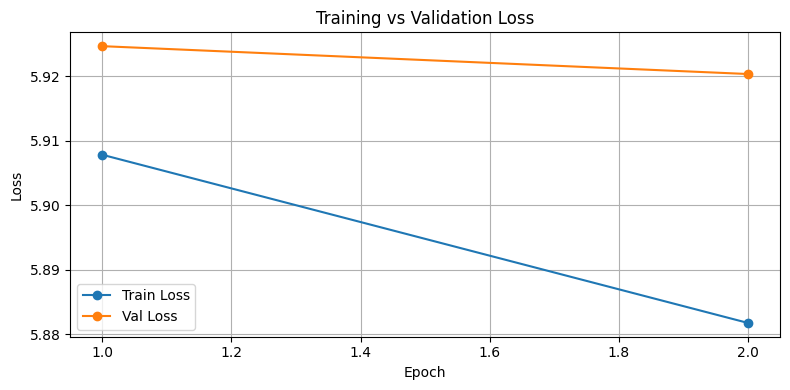

Model saved!


In [23]:
import matplotlib.pyplot as plt

# Loss plot
plt.figure(figsize=(8, 4))
plt.plot([1,2], train_losses, marker='o', label='Train Loss')
plt.plot([1,2], val_losses,   marker='o', label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/kaggle/working/loss_plot.png')
plt.show()

# Model save 
model.save_pretrained('/kaggle/working/qwen_vlm_lora')
processor.save_pretrained('/kaggle/working/qwen_vlm_lora')
print("Model saved!")

In [24]:
from qwen_vl_utils import process_vision_info

def generate_markdown(image_path):
    try:
        image = Image.open(image_path).convert('RGB').resize((512, 512))
    except:
        return "Error loading image"

    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Convert this document image to Markdown."}
        ]}
    ]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = processor(
        text=[text], images=[image],
        return_tensors="pt"
    ).to(device)

    model.eval()
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=200,
            do_sample=False
        )

    generated = processor.decode(
        output_ids[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    return generated

# 3 training images test 
print("="*60)
for i in range(3):
    img_path = train_pairs[i]['image']
    with open(train_pairs[i]['markdown'], 'r') as f:
        ground_truth = f.read()[:200]

    generated = generate_markdown(img_path)

    print(f"\n--- Training Sample {i+1} ---")
    print(f"Ground Truth : {ground_truth[:150]}")
    print(f"Generated    : {generated[:150]}")
    print("="*60)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



--- Training Sample 1 ---
Ground Truth : sigma_{0}\) as indicated by \(S(z)\to-1/2\). This observation is merely due to the electrostatic wall-PE binding whose strength scales like \(\sigma_{
Generated    : especially strong at low \(\sigma_{0}\) and (ii) repulsive image forces induce orientational disorder as previously established. This finding leads to

--- Training Sample 2 ---
Ground Truth : and Hall coefficient \(R_{H}\)

\[\frac{\Delta\rho(B)}{\rho(0)} \!\!\!= \!\!\!4\exp\left(-\frac{\pi}{\omega_{c}\tau}\right)\cos 2\pi\frac {E_{0}}{\ome
Generated    : and Hall coefficient \(R_{H}\)

\[\Delta B(\rho)_{0}=4\exp\left(-\frac{\pi}{\omega_{c}}\right)\cos2\pi\frac{E_{0}}{\omega_{c}}\cos\frac{\Omega_{B}}{\o

--- Training Sample 3 ---
Ground Truth : a fourth order Runge-Kutta method. Trajectories of cosmic rays were calculated until they left the Galaxy. Testing the differential scheme used, it wa
Generated    : a fourth order Runge-Kutta method. Trajectories of cosmic rays were calcul

/tmp/ipykernel_57/3070872321.py:34: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


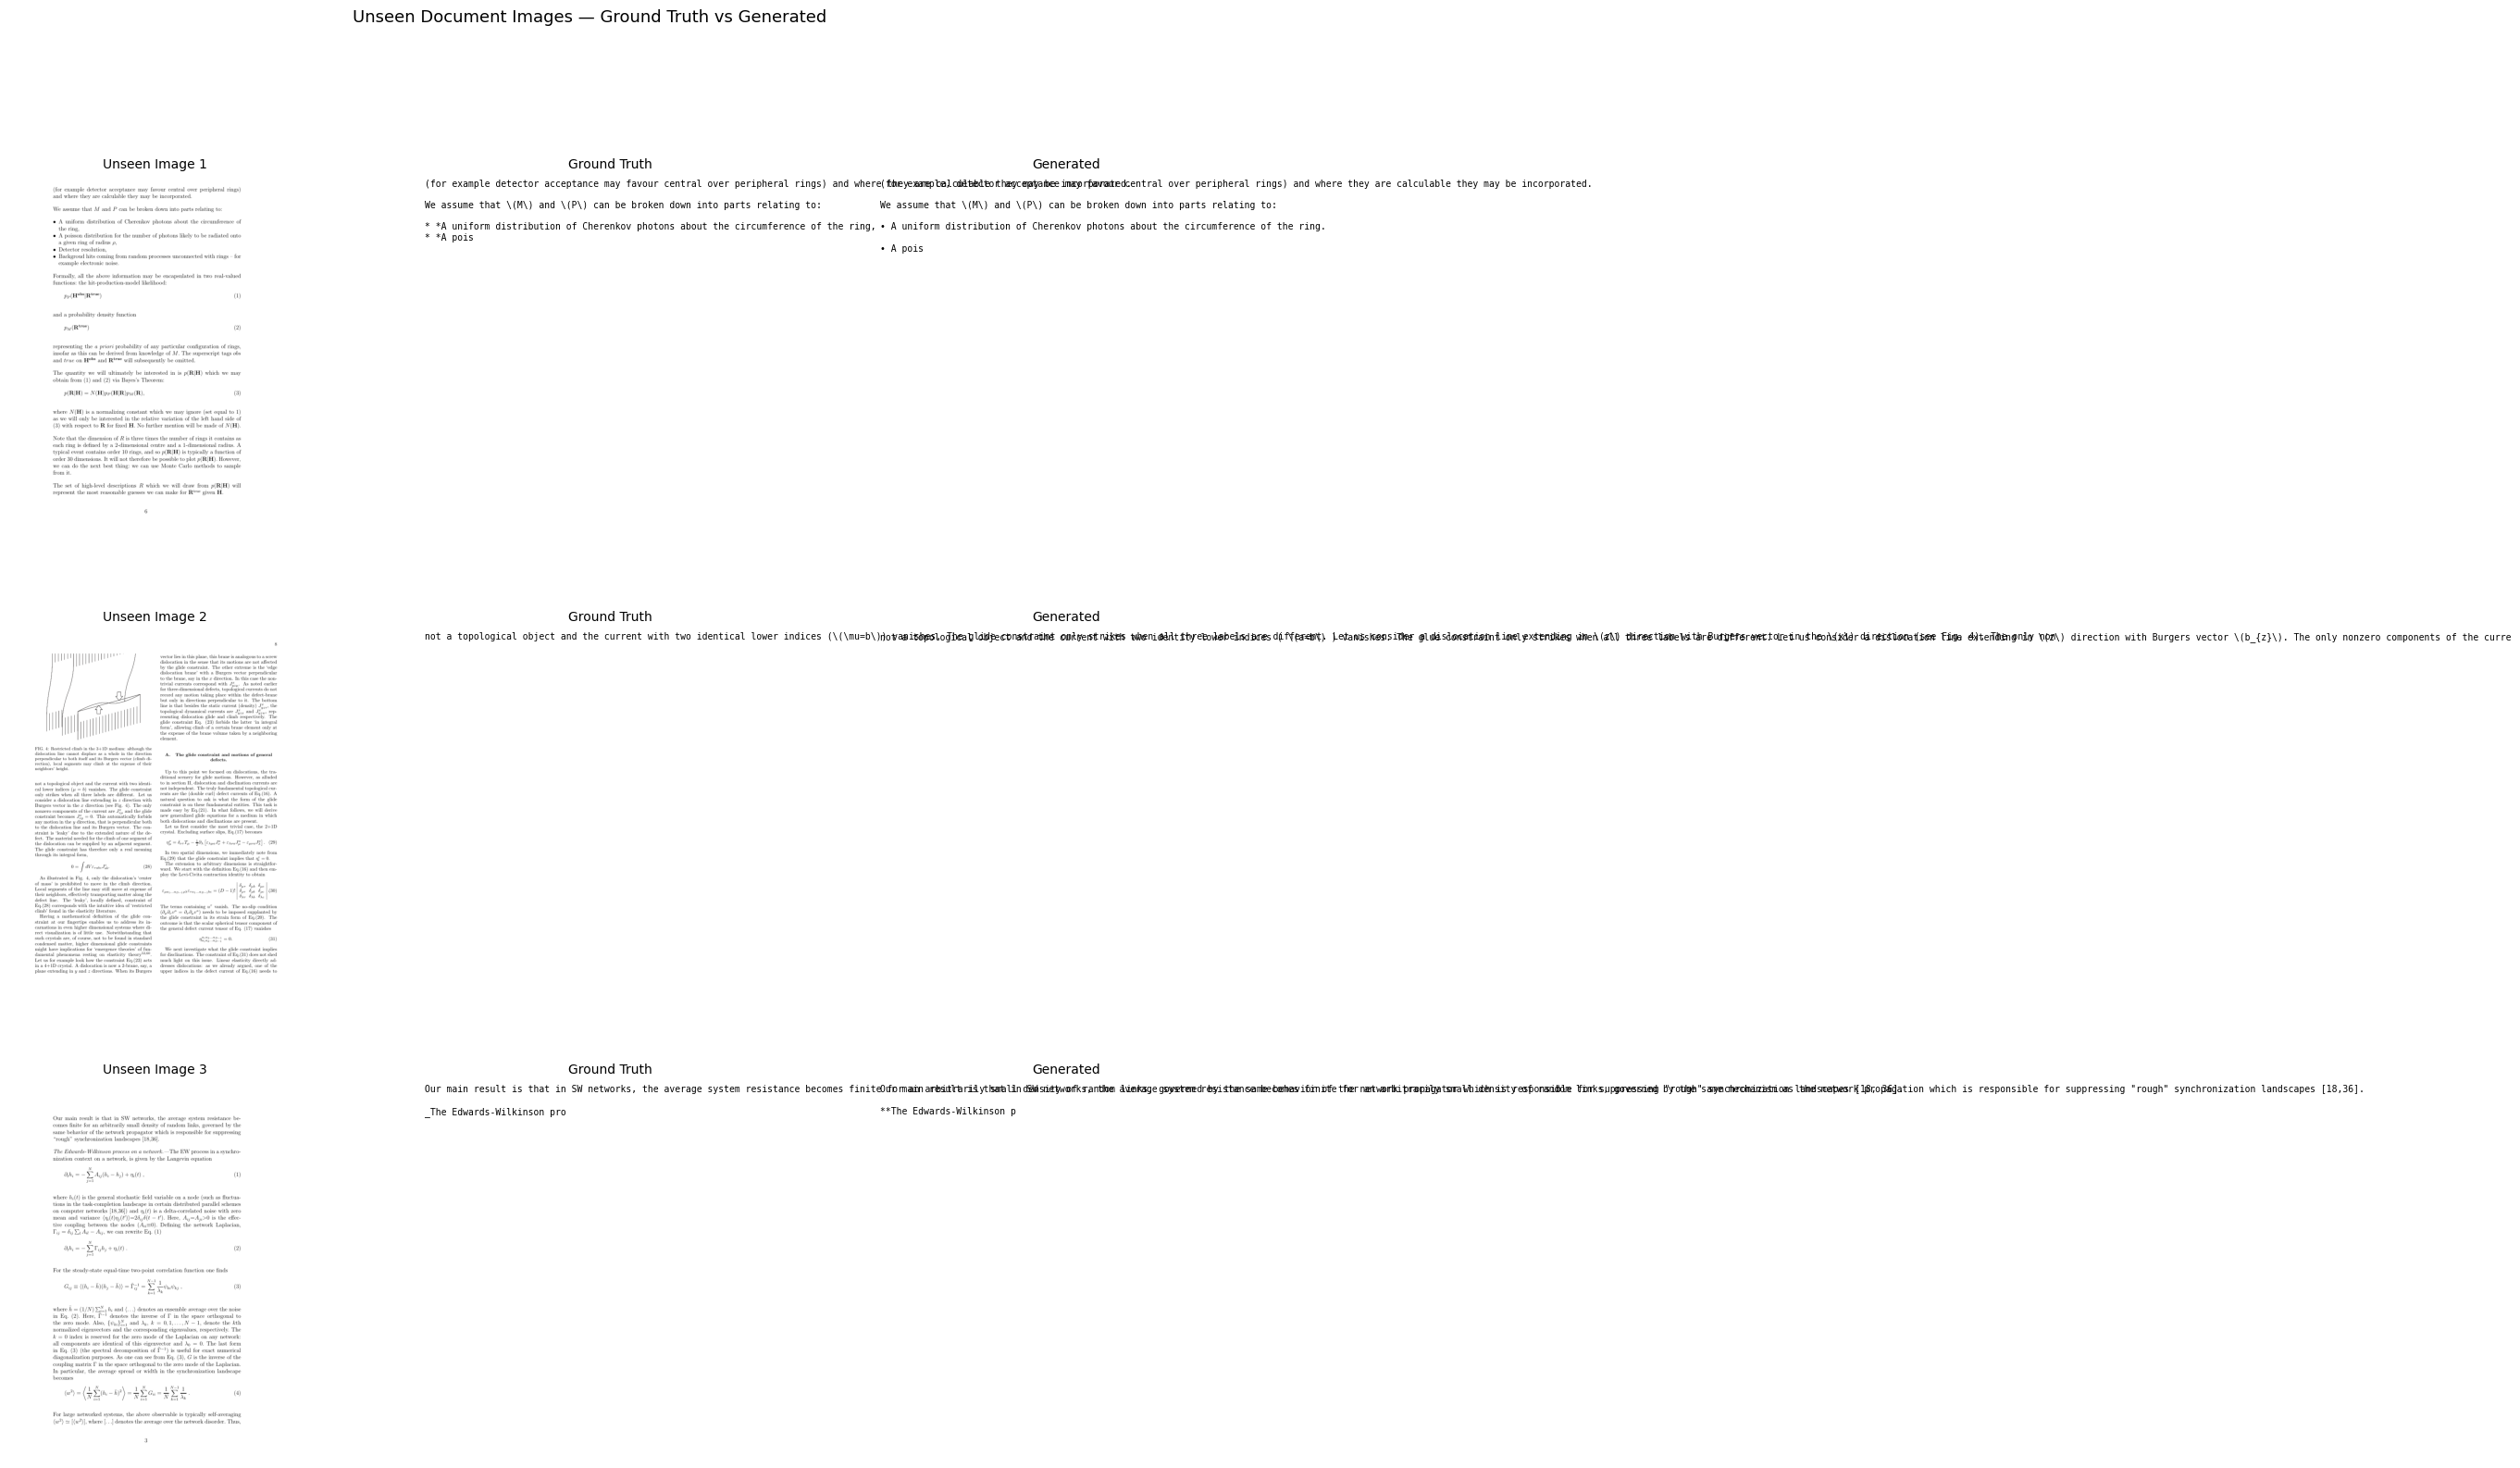

Done!


In [25]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 3 validation (unseen) images test karo
fig = plt.figure(figsize=(18, 18))

for i in range(3):
    img_path = val_pairs[i]['image']
    with open(val_pairs[i]['markdown'], 'r') as f:
        ground_truth = f.read()[:300]

    generated = generate_markdown(img_path)
    image = Image.open(img_path).convert('RGB')

    # 3 columns: Image | Ground Truth | Generated
    ax1 = fig.add_subplot(3, 3, i*3 + 1)
    ax1.imshow(image)
    ax1.set_title(f'Unseen Image {i+1}', fontsize=10)
    ax1.axis('off')

    ax2 = fig.add_subplot(3, 3, i*3 + 2)
    ax2.text(0.01, 0.99, ground_truth[:300], transform=ax2.transAxes,
             fontsize=7, verticalalignment='top', fontfamily='monospace')
    ax2.set_title('Ground Truth', fontsize=10)
    ax2.axis('off')

    ax3 = fig.add_subplot(3, 3, i*3 + 3)
    ax3.text(0.01, 0.99, generated[:300], transform=ax3.transAxes,
             fontsize=7, verticalalignment='top', fontfamily='monospace')
    ax3.set_title('Generated', fontsize=10)
    ax3.axis('off')

plt.suptitle('Unseen Document Images — Ground Truth vs Generated', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/unseen_results.png', dpi=150)
plt.show()
print("Done!")

In [26]:
!pip install -q gradio

import gradio as gr

def predict_markdown(image):
    image = image.resize((512, 512))
    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Convert this document image to Markdown."}
        ]}
    ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt").to(device)
    
    model.eval()
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=300, do_sample=False)
    
    generated = processor.decode(
        output_ids[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    return generated

demo = gr.Interface(
    fn=predict_markdown,
    inputs=gr.Image(type="pil", label="Upload Document Image"),
    outputs=gr.Textbox(label="Generated Markdown", lines=15),
    title="Document to Markdown Generator",
    description="Upload a document image and get Markdown output!"
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://50b1b607b59133b13a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [27]:
# Zero-shot: Original model 
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

original_model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

test_img = val_pairs[0]['image']
image = Image.open(test_img).convert('RGB').resize((512,512))

# Zero-shot output
messages = [{"role": "user", "content": [
    {"type": "image", "image": image},
    {"type": "text", "text": "Convert this document image to Markdown."}
]}]
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=[text], images=[image], return_tensors="pt").to(device)
with torch.no_grad():
    out = original_model.generate(**inputs, max_new_tokens=150, do_sample=False)
zero_shot = processor.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

# Fine-tuned output
finetuned = generate_markdown(test_img)

print("ZERO-SHOT OUTPUT:")
print(zero_shot[:300])
print("\nFINE-TUNED OUTPUT:")
print(finetuned[:300])

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

ZERO-SHOT OUTPUT:
(for example, detector acceptance may favour central over peripheral rings) and where they are calculable they may be incorporated. We assume that M and P can be broken down into parts relating to: • A uniform distribution of Cherenkov photons about the circumference of the ring. • A poisson distrib

FINE-TUNED OUTPUT:
(for example, detector acceptance may favour central over peripheral rings) and where they are calculable they may be incorporated.

We assume that \(M\) and \(P\) can be broken down into parts relating to:

• A uniform distribution of Cherenkov photons about the circumference of the ring.

• A pois


In [28]:
# Different Prompt Styles Compare

test_img = val_pairs[1]['image']
image = Image.open(test_img).convert('RGB').resize((512, 512))

prompts = {
    "Simple": "Convert this document image to Markdown.",
    "Detailed": "You are an expert document parser. Carefully analyze this academic document image and convert all text, headings, equations, and bullet points into proper Markdown format.",
    "Instructive": "Extract the text from this document image. Format headings with #, subheadings with ##, bullet points with -, and math equations with LaTeX notation."
}

results = {}
for style, prompt in prompts.items():
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": prompt}
    ]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt").to(device)
    
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=150, do_sample=False)
    
    results[style] = processor.decode(
        out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
    )

# Print comparison
for style, output in results.items():
    print(f"\n{'='*50}")
    print(f"PROMPT STYLE: {style}")
    print(f"{'='*50}")
    print(output[:250])


PROMPT STYLE: Simple
not a topological object and the current with two identity lower indices ( \(a=b\) ) vanishes. The glue constraint only strikes when all three labels are different. Let us consider a dislocation line extending in \(z\) direction with Burgers vector \

PROMPT STYLE: Detailed
not a topological object and the current with two identical lower indices \((a=b)\) vanishes. The glue constraint only strikes when all three labels are different. Let us consider a dislocation line extending in z direction with Burgers vector \(b_{z

PROMPT STYLE: Instructive
not a topological object and the current with two identical lower indices ( \(a=b\) ) vanishes. The glue constraint only strikes when all three labels are different. Let us consider a dislocation line extending in z direction with Burgers vector \(b_


Training 3 more epochs (total 5)...


Epoch 3/5 Train:   0%|          | 0/399 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 3/5 Val:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 3 | Train Loss: 5.8647 | Val Loss: 5.9200


...

Epoch 4/5 Val:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 4 | Train Loss: 5.8490 | Val Loss: 5.9241


Epoch 5/5 Train:   0%|          | 0/399 [00:00<?, ?it/s]

Epoch 5/5 Val:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 5 | Train Loss: 5.8354 | Val Loss: 5.9307


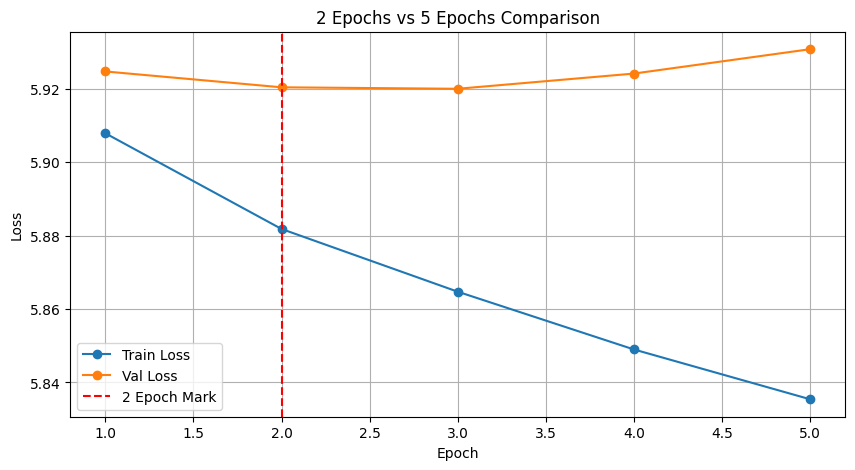

2 EPOCH OUTPUT (saved earlier):
(for example, detector acceptance may favour central over peripheral rings) and where they are calculable they may be incorporated.

We assume that \(M\) and \(P\) can be broken down into parts relati

5 EPOCH OUTPUT:
Our main result is that in SW networks, the average system resistance comes finite for an arbitrarily small density of random links, governed by the same behavior of the network propagation which is r


In [29]:


print("Training 3 more epochs (total 5)...")

EXTRA_EPOCHS = 3
extra_train_losses = []
extra_val_losses = []

for epoch in range(EXTRA_EPOCHS):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+3}/{5} Train"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()

    avg_train = total_loss / len(train_loader)
    extra_train_losses.append(avg_train)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+3}/{5} Val"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            val_loss += outputs.loss.item()

    avg_val = val_loss / len(val_loader)
    extra_val_losses.append(avg_val)
    print(f"Epoch {epoch+3} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

# Compare plot
all_train = train_losses + extra_train_losses
all_val   = val_losses + extra_val_losses

plt.figure(figsize=(10, 5))
plt.plot(range(1, 6), all_train, marker='o', label='Train Loss')
plt.plot(range(1, 6), all_val,   marker='o', label='Val Loss')
plt.axvline(x=2, color='red', linestyle='--', label='2 Epoch Mark')
plt.title('2 Epochs vs 5 Epochs Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('/kaggle/working/epoch_comparison.png')
plt.show()

# Output compare
test_img = val_pairs[2]['image']

# 5 epoch output
output_5ep = generate_markdown(test_img)

print("2 EPOCH OUTPUT (saved earlier):")
print(finetuned[:200])
print("\n5 EPOCH OUTPUT:")
print(output_5ep[:200])